In [15]:
pip install pandas sqlalchemy pyodbc matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [68]:
#connection information
SERVER  = "L47P\\SQLEXPRESS"
DATABASE = "StarWars"
ODBC_DRIVER = "ODBC Driver 17 for SQL Server"

#creating ODBC string, how Python will authenticate interface between Python and SQL Server database
odbc_str = (
    "Driver={" + ODBC_DRIVER + "};"
    "Server=" + SERVER + ";"
    "Database=" + DATABASE + ";"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
    "TrustServerCertificate=yes;"
)

#creating engine, a reuseable connection between Python and SQL Server
engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" + quote_plus(odbc_str)
)

print("Engine created")

Engine created


In [67]:
#loading the tables to Python memory for analysis
with engine.connect() as conn:
    planets = pd.read_sql("SELECT * FROM dbo.Planets", conn)
    characters = pd.read_sql("SELECT * FROM dbo.Characters", conn)
    ships = pd.read_sql("SELECT * FROM dbo.StarshipsVehicles", conn)
    weapons = pd.read_sql("SELECT * FROM dbo.Weapons", conn)
    
print("All tables loaded")

All tables loaded


In [165]:
planets
#Information about various planets in Star Wars, indlucing their name, region, climate, terrain and population. 
#Serving as the georaphical backbone of the dataset.

,PlanetID,PlanetName,Region,Climate,Terrain,Population
0,1,Tatooine,Outer Rim,"Arid, hot","Desert, dunes, rocky canyons",2.000000e+05
1,2,Alderaan,Core Worlds,Temperate,"Grasslands, mountains, forests",2.000000e+09
2,3,Coruscant,Core Worlds,"Temperate, artificial",Ecumenopolis (city-planet),1.000000e+12
3,4,Naboo,Mid Rim,"Temperate, tropical","Plains, lakes, swamps",4.500000e+09
4,5,Mustafar,Outer Rim,"Hot, volcanic","Lava rivers, volcanic mountains",2.000000e+04
5,6,Hoth,Outer Rim,"Frozen, frigid","Ice fields, tundra, glaciers",NaN
6,7,Endor (forest moon),Outer Rim,"Mild, temperate","Forests, mountains, rivers",3.000000e+07
7,8,Kashyyyk,Mid Rim,"Tropical, humid","Wroshyr forests, rivers",4.500000e+07
8,9,Kamino,Extragalactic,"Rainy, stormy","Endless oceans, stormy seas",1.000000e+09
9,10,Geonosis,Outer Rim,"Hot, arid","Rocky deserts, mesas, hive structures",1.000000e+08


In [166]:
characters
#Contains key Star Wars characters, affiliations, gender, birth year (age) and Force-sensitivity.
#The characters are linked via their homeworlds to the entire dataset.

,CharacterID,Cname,Species,HomeworldID,Affiliation,Gender,BirthYear,IsForceSensitive
0,1,Luke Skywalker,Human,1.0,Rebel Alliance,Male,19.0,True
1,2,Anakin Skywalker,Human,1.0,Jedi Order / Sith,Male,41.0,True
2,3,Shmi Skywalker,Human,1.0,None,Female,NaN,False
3,4,Leia Organa,Human,2.0,Rebel Alliance,Female,19.0,True
4,5,Bail Organa,Human,2.0,Galactic Senate,Male,67.0,False
5,6,Sheev Palpatine,Human,3.0,Galactic Empire,Male,84.0,True
6,7,Mas Amedda,Chagrian,3.0,Galactic Senate,Male,NaN,False
7,8,Padmé Amidala,Human,4.0,Galactic Senate,Female,46.0,False
8,9,Jar Jar Binks,Gungan,4.0,Galactic Senate,Male,52.0,False
9,10,Darth Maul,Zabrak,14.0,Sith,Male,54.0,True


In [167]:
ships
#A dataset about Starships and vehicles in the Star Wars universe. Including classes, crew capacity, max speed, and current regions.
# This enables a comparison of various transportation methods accross the galaxy.

,VehicleID,ShipName,ShipType,Class,Model,Manufacturer,CrewCapacity,CargoCapacityKg,HyperdriveRating,MaxAtmosphericSpeedKph,OwnerCharacterID,CurrentPlanetID
0,1,Millennium Falcon,Starship,Freighter,YT-1300f,Corellian Engineering Corporation,2,100000,0.5,NaN,16.0,11.0
1,2,Red Five,Starship,Starfighter,T-65B X-wing,Incom Corporation,1,110,1.0,1050.0,1.0,24.0
2,3,TIE Advanced x1,Starship,Starfighter,TIE/x1,Sienar Fleet Systems,1,65,1.0,NaN,22.0,NaN
3,4,N-1 Starfighter,Starship,Starfighter,N-1,Theed Palace Space Vessel Eng. Corps,1,50,1.0,1100.0,2.0,4.0
4,5,Jedi Starfighter,Starship,Starfighter,Delta-7 Aethersprite,Kuat Systems Engineering,1,20,1.0,1150.0,20.0,10.0
5,6,LAAT/i Gunship,Vehicle,Gunship,LAAT/i,Rothana Heavy Engineering,6,1000,NaN,620.0,NaN,10.0
6,7,AT-AT Walker,Vehicle,Walker,All Terrain Armored Transport,Kuat Drive Yards,5,10000,NaN,60.0,22.0,6.0
7,8,AT-ST Walker,Vehicle,Walker,All Terrain Scout Transport,Kuat Drive Yards,2,2000,NaN,90.0,NaN,7.0
8,9,Lambda-class Shuttle,Starship,Shuttle,T-4a,Sienar Fleet Systems,6,800,1.0,850.0,22.0,7.0
9,10,Ghost,Starship,Light Freighter,VCX-100,Corellian Engineering Corporation,4,70000,1.0,NaN,24.0,18.0


In [168]:
weapons
# A list of weapons in the Star Wars universe, including weapon type, restriction.
# Through a connection to the weapon's primary wiedler, we can analyze weapon distribution and useage patterns.

,WeaponID,WeaponName,WeaponCategory,DamageType,Era,Material,IsRestricted,PrimaryWielderID,Notes
0,1,Luke's Lightsaber (green),Lightsaber,Energy,Galactic Civil War,kyber (green),True,1.0,None
1,2,Anakin's Lightsaber (blue),Lightsaber,Energy,Clone Wars,kyber (blue),True,2.0,Later passed to Luke/Leia
2,3,Darth Vader's Lightsaber,Lightsaber,Energy,Galactic Civil War,kyber (red),True,22.0,None
3,4,Obi-Wan Kenobi's Lightsaber,Lightsaber,Energy,Clone Wars,kyber (blue),True,20.0,None
4,5,Darth Maul's Double-Bladed Saber,Lightsaber,Energy,Prequel Era,kyber (red),True,10.0,None
5,6,Count Dooku's Curved-Hilt Saber,Lightsaber,Energy,Clone Wars,kyber (red),True,21.0,None
6,7,Yoda's Lightsaber,Lightsaber,Energy,Clone Wars,kyber (green),True,19.0,None
7,8,Han Solo's DL-44,Blaster,Energy,Galactic Civil War,None,True,16.0,Heavy blaster pistol
8,9,Leia's Sporting Blaster (ELG-3A),Blaster,Energy,Galactic Civil War,None,True,4.0,None
9,10,Chewbacca's Bowcaster,Bowcaster,Energy,Galactic Civil War,None,True,18.0,None


  PlanetName  ForceSensitiveCount
1  Coruscant                    3
4   Tatooine                    3
0   Alderaan                    1
2   Dathomir                    1
3     Lothal                    1


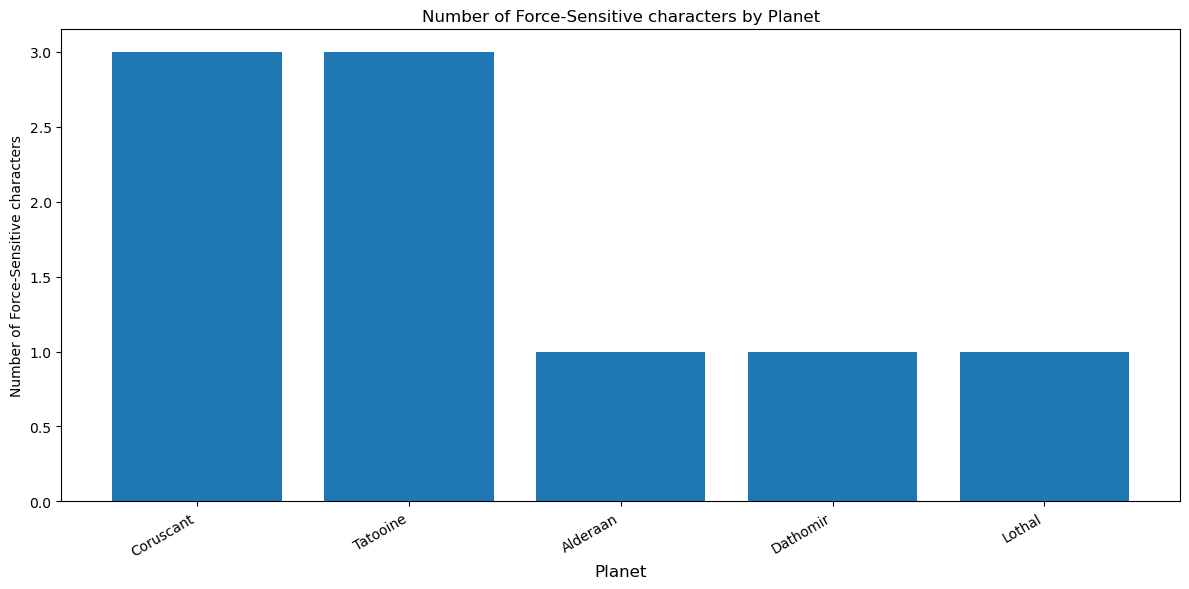

In [164]:
import matplotlib.pyplot as plt
%matplotlib inline

#GRAPH 1
#joining the tables of interest
df = characters.merge(
    planets,
    left_on="HomeworldID",
    right_on="PlanetID",
    how="inner",
)
#filtering the Force users
force_users = df[df["IsForceSensitive"] ==True]

summary = (
    force_users
    .groupby("PlanetName")
    .size()
    .reset_index(name="ForceSensitiveCount")
    .sort_values("ForceSensitiveCount", ascending = False)
)
print (summary)

#creating the graph
plt.figure(figsize=(12,6))
plt.bar(summary["PlanetName"], summary['ForceSensitiveCount'])
plt.title("Number of Force-Sensitive characters by Planet")
plt.ylabel("Number of Force-Sensitive characters")
plt.xlabel("Planet", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

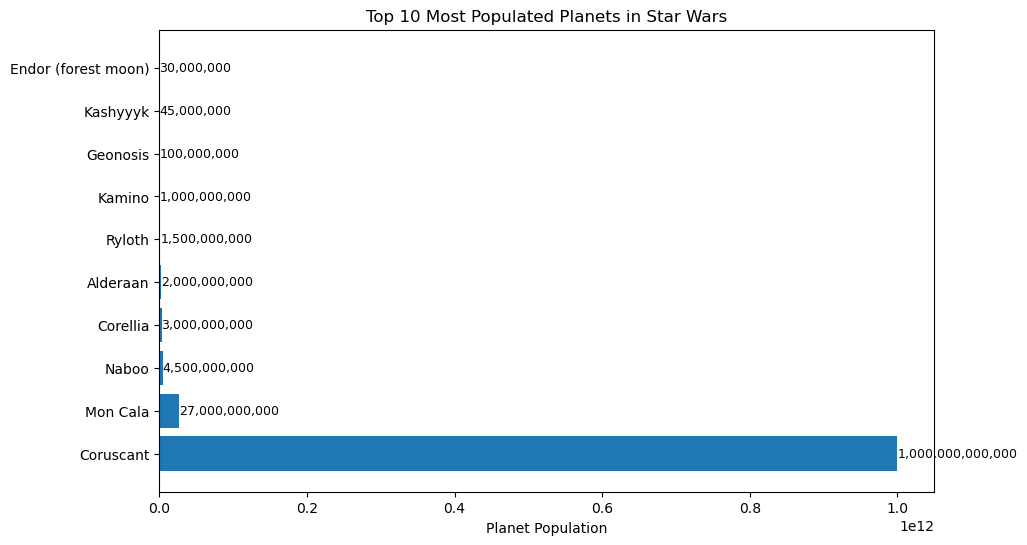

In [118]:
top_planets = planets.sort_values("Population", ascending=False).head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_planets["PlanetName"], top_planets["Population"])
plt.xlabel("Planet Population")
plt.title("Top 10 Most Populated Planets in Star Wars")
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )
plt.show()

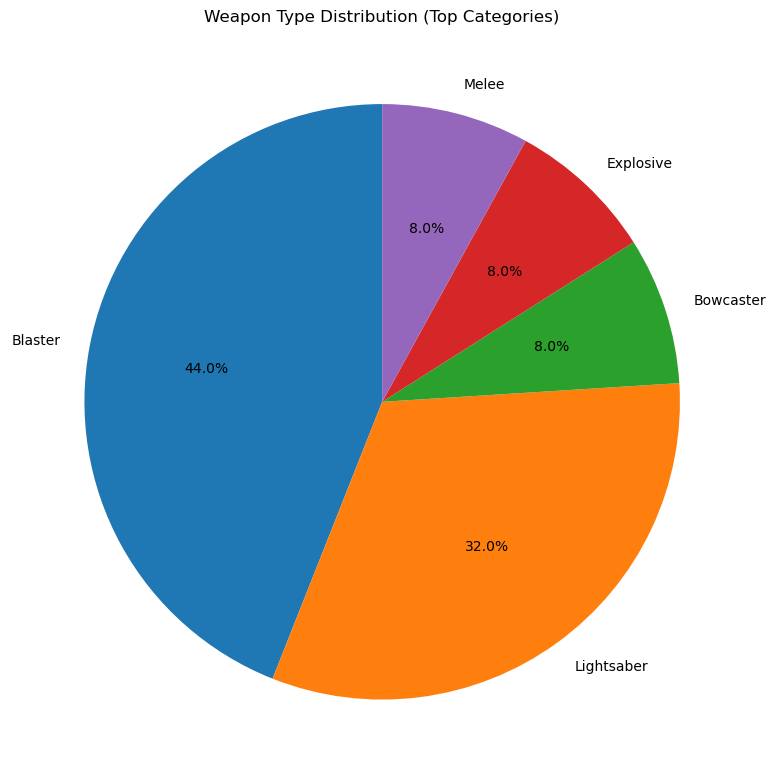

WeaponCategory
Blaster       11
Lightsaber     8
Bowcaster      2
Explosive      2
Melee          2
Name: count, dtype: int64

In [128]:
#Graph 3 
#counting how many times each weapons appears in each weapon catergory
weapon_counts = (
    weapons["WeaponCategory"]
    .fillna("Unknown")
    .value_counts()
)

#creating the plot
plt.figure(figsize=(8,8))
plt.pie(
    weapon_counts.values,
    labels=weapon_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Weapon Type Distribution (Top Categories)")
plt.tight_layout()
plt.show()

weapon_counts

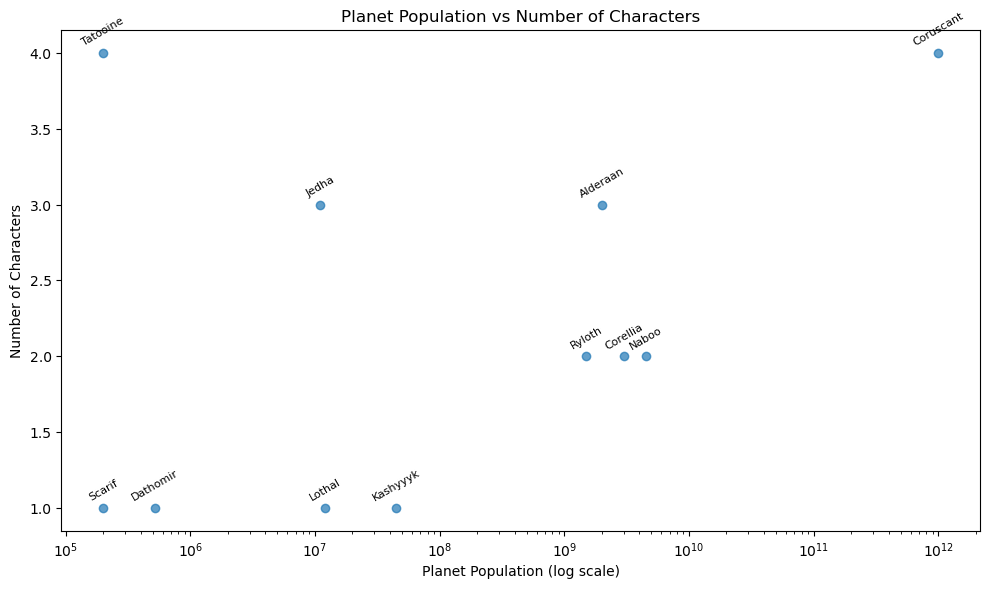

In [149]:
#Graph 4

char_counts = characters.groupby("HomeworldID").size().reset_index(name="CharacterCount")

df_scatter = char_counts.merge(
    planets,
    left_on="HomeworldID",
    right_on="PlanetID"
)
#adding a scatter plot
plt.figure(figsize=(10,6))
plt.scatter(
    df_scatter["Population"],
    df_scatter["CharacterCount"],
    alpha=0.7
)
plt.xscale("log")
plt.xlabel("Planet Population (log scale)")
plt.ylabel("Number of Characters")
plt.title("Planet Population vs Number of Characters")

#adding labels
for _, row in df_scatter.iterrows():
    plt.text(
        row["Population"],
        row["CharacterCount"] + 0.05,
        row["PlanetName"],
        fontsize=8,
        rotation=30,
        ha="center"
    )
    
plt.tight_layout()
plt.show()

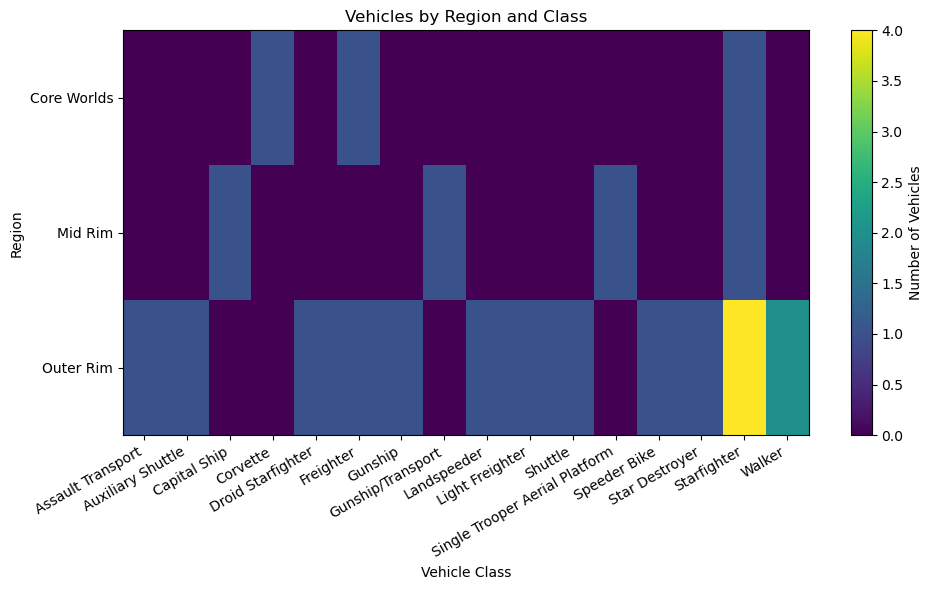

In [162]:
#Graph 5

#joining vehicles to planets
v = ships.merge(
    planets[["PlanetID", "Region"]],
    left_on="CurrentPlanetID",
    right_on="PlanetID",
    how="left"
)

#counting vehicles by region and type
pivot = (
    v.pivot_table(index="Region", columns="Class", values="VehicleID", aggfunc="count", fill_value=0)
)

#heatmap plot
plt.figure(figsize=(10,6))
plt.imshow(pivot.values, aspect="auto")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Number of Vehicles")
plt.title("Vehicles by Region and Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [163]:
#Conclusions:
#Graph 1: Force-Sensitive characters are more concentrated on a small number of planets, rather than being evenly distributed over the galaxy. 
        #A few planets show a higher concentraion of Force-Sensitive individuals, suggestion that certain world may play a significat role in Jedi/Sith history.

#Graph 2: Planet populations vary dramatically, with Coruscant standing out as a significant outlier compared to other planets.
        # Even among the top 10, other planets' populations are much smaller, highlighting a strong imbalance in galactic population distribution.

#Graph 3: The Weapon distribution shows that a small bunber of weapon types dominate the dataset. This suggests that combat in the Star Wars universe relies
        # on a few weapon catergories, while more specialized or restricted weapons are relatively rare.

#Graph 4: There is no strong direct relationship between a planet's population size and the number of major characters originating from it.
        # Some major world only have a few notable characters, while other smaller planets can still be important due to narrative/political signifince.

#Graph 5: Vehicle availability and diversity vary noticably by region. The Core Worlds tend to show fewer but more advanced/specialized vehicles, while
        # the Outer Rim shows greater variety, mainly in military and utility vehicle classes. These changes reflect differences in inftrastructues, 
        # technology classes and political control accross regions.